# Esame Laboratorio di Programmazione II - 13/01/2026


Scrivete chiaramente sul notebook il vostro nome e matricola e sul nome con cui salvate il file la vostra matricola.

Per ogni funzione e metodo che richiede un campionamento rispetto ad una distribuzione settate il seed a 0: ``np.random.seed(0)``.

Stampate il risultato delle domanda e consegnate il compito eseguito, quindi per cui ogni cella ha il corrispondente output.
Quindi ad esempio

e.g., 
NON scrivete: 
```python 
    lista=np.array([1,2,3])
```
ma 
```python
    lista=np.array([1,2,3]) 
    print('lista =', lista)   
```
Attenzione!Se scrivete:
```python
    lista=np.array([1,2,3])
    lista
```
``lista`` sarà l'unico ouput che si vede di quella cella

NB se l'output è una matrice molto grande non dovete stamparla.

Sarà valutata anche la presentazione, ad esempio un plot senza ettichette sugli assi o illleggibili sarà valutato meno bene di uno con ettichette chiare.

Commentate il compito di modo che si capisca cosa avete fatto.

Controllate attentamente di avere consegnato il file giusto.

In [2]:
#Potete importare direttamente qui le librerie che userete
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Esercizio 1
Un sensore ha registrato le seguenti temperature giornaliere (in °C) durante 12 giorni consecutivi:  
`18, 21, 19, 23, 25, 22, 20, 24, 26, 27, 21, 19`

1. Calcola la temperatura media del periodo.  
2. A causa di una ricalibrazione, tutte le temperature superiori a 22 °C devono essere aumentate di 1 °C. Aggiorna il vettore.  
3. Quanti giorni hanno registrato una temperatura pari o superiore a 25 °C dopo la ricalibrazione?


In [ ]:
temperature = np.array([18,21,19,23,25,22,20,24,26,27,21,19])
t_media = temperature.mean()
ricalibrazione = np.where(temperature > 22, temperature + 1, temperature)
t_25 = len(ricalibrazione[ricalibrazione >= 25])
# t_25 = np.sum(ricalibrazione >= 25)

print(f"Temperature: {temperature}\nTemperatura media: {t_media}\nRicalibrazione: {ricalibrazione}\nNumero giorni con temperature maggiori o uguali a 25: {t_25}")

Temperature: [18 21 19 23 25 22 20 24 26 27 21 19]
Temperatura media: 22.083333333333332
Ricalibrazione: [18 21 19 24 26 22 20 25 27 28 21 19]
Numero giorni con temperature maggiori o uguali a 25: 4


## Esercizio 2

Un’urna contiene **3 palline rosse** e **2 palline blu**.  
Dopo ogni estrazione la pallina viene **rimessa nell’urna**.

1. Scrivi una funzione che simula **N estrazioni** e restituisce un array NumPy (`1 = rossa`, `0 = blu`).

2. Per valori di N pari a 50, 100, 150, …, 500:
   - ripeti la simulazione **100 volte**
   - calcola la **frequenza relativa media** delle palline rosse.

3. Rappresenta graficamente l’**andamento della frequenza relativa media delle palline rosse** in funzione del numero di estrazioni.


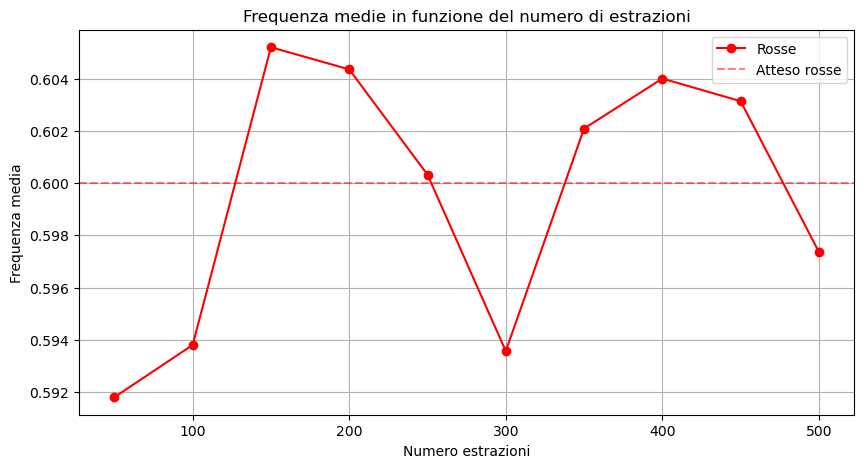

In [13]:
def estrazione(n):
    risultato = np.random.choice([0,1], size = n, p = [2/5, 3/5])
    return risultato


intervalli = np.arange(50, 501, 50)
f_medie = []

for n in intervalli:
    # 100 simulazioni da n estrazioni ciascuna → matrice 100 x n
    simulazioni = np.array([estrazione(n) for _ in range(100)])
    # media per ogni simulazione → array di 100 frequenze
    frequenze = simulazioni.mean(axis=1)
    # media delle 100 frequenze
    f_medie.append(frequenze.mean())

plt.figure(figsize=(10,5))
plt.plot(intervalli, f_medie, marker='o', color='red', label='Rosse')
plt.axhline(y=3/5, color='red', linestyle='--', alpha=0.5, label='Atteso rosse')
plt.title('Frequenza medie in funzione del numero di estrazioni')
plt.xlabel('Numero estrazioni')
plt.ylabel('Frequenza media')
plt.legend()
plt.grid(True)
plt.show()

## Esercizio 3

1. Genera una matrice NumPy di dimensioni **6 x 8**, con valori estratti da una distribuzione normale con **media = 2** e **deviazione standard = 3**.

2. Per ogni riga, individua il valore **più vicino a zero** (cioè con valore assoluto minimo). Crea un array con questi **6 valori** (uno per riga).

3. Calcola quante righe hanno come valore più vicino a zero un numero **negativo**.


In [ ]:
matrice = np.random.normal(loc=2, scale=3, size=(6, 8))

valori_vicini = []
n = 0

for riga in matrice:
    idx = np.argmin(np.abs(riga))   # indice del valore con abs minimo
    valore = riga[idx]              # valore originale (con segno)
    valori_vicini.append(valore)
    if valore < 0:
        n += 1

valori_vicini = np.array(valori_vicini)
print(f"Matrice:\n{matrice}\nValori più vicini a zero: {valori_vicini}\nRighe con valore negativo: {n}")

In [ ]:
# perdo informazione per claude, la soluzione migliore è quella sopra
matrice = np.random.normal(loc = 2, scale = 3, size=(6,8))

array = []
n = 0
for i, riga in enumerate(matrice):
    valore_assoluto = np.where(riga <0, riga*-1, riga)
    minimo = min(valore_assoluto)
    array.append(minimo)
    if minimo not in riga:
        n +=1
print(f"Matrice: {matrice}\nArray: {array}\nN: {n}")

Matrice: [[ 3.93059228  0.65698739 -2.08195884  3.05122966  6.26657046  2.43471702
   2.90125004  5.09207711]
 [ 2.9425695   1.54681354  4.26399211  3.60381618  0.77256212  1.07507876
  -3.61724056  6.05246498]
 [ 1.46500223  1.99429005  1.27675116  8.87060256  8.12765195  3.18174371
   3.76456919  4.32833954]
 [ 1.03311037  4.26791946  6.61272377 -0.56453793  1.26886568 -1.5148516
  -2.21552323  6.29083677]
 [ 3.13292787  1.64598134  2.13371286 -2.08209206 -1.26048845  2.03613612
   1.67282606  1.48650078]
 [ 2.97559553  7.27308058  8.76203616  3.06215516  0.95109647  4.01003638
   3.43631558  3.34178441]]
Array: [np.float64(0.6569873852792927), np.float64(0.7725621246269958), np.float64(1.2767511638551376), np.float64(0.5645379270880695), np.float64(1.2604884526122433), np.float64(0.9510964709232601)]
N: 2


In [3]:
# ===========================================================================
# (Setup) creazione dataset `students.csv` (da eseguire una sola volta)
# ===========================================================================

def make_students_csv(filename="students.csv", n=60, seed=42):
    """
    Dataset più "significativo":
    - exam_score cresce (non linearmente) con study_hours e attendance
    - presenza di cluster (studenti regolari / altalenanti / molto bravi)
    - qualche outlier (molte ore ma voto medio, poche ore ma voto alto)
    - qualche valore mancante
    """
    rng = np.random.default_rng(seed)

    student_id = np.arange(1, n + 1)

    group = rng.choice([0, 1, 2], size=n, p=[0.45, 0.40, 0.15])

    study_hours = np.empty(n, dtype=int)
    attendance = np.empty(n, dtype=float)

    idx0 = group == 0
    study_hours[idx0] = rng.integers(12, 28, size=idx0.sum())
    attendance[idx0] = rng.uniform(0.78, 1.00, size=idx0.sum())

    idx1 = group == 1
    study_hours[idx1] = rng.integers(5, 22, size=idx1.sum())
    attendance[idx1] = rng.uniform(0.60, 0.95, size=idx1.sum())

    idx2 = group == 2
    study_hours[idx2] = rng.integers(22, 45, size=idx2.sum())
    attendance[idx2] = rng.uniform(0.85, 1.00, size=idx2.sum())

    attendance = np.round(attendance, 2)

    noise = rng.normal(0, 6, size=n)
    nonlinear_bonus = 8 / (1 + np.exp(-(study_hours - 25) / 4))  # "curva a S"
    exam_score = 35 + 1.4 * study_hours + 22 * (attendance - 0.6) + nonlinear_bonus + noise
    exam_score = np.clip(exam_score, 35, 100)
    exam_score = np.round(exam_score).astype(float)

    for i in rng.choice(np.where(study_hours > 30)[0], size=min(2, np.sum(study_hours > 30)), replace=False):
        exam_score[i] = max(40, exam_score[i] - rng.integers(12, 20))

    for i in rng.choice(np.where(study_hours < 12)[0], size=min(2, np.sum(study_hours < 12)), replace=False):
        exam_score[i] = min(100, exam_score[i] + rng.integers(12, 20))

    p_pass = 1 / (1 + np.exp(-(exam_score - 62) / 6))
    passed = (rng.uniform(0, 1, size=n) < p_pass).astype(int)

    df = pd.DataFrame({
        "student_id": student_id,
        "exam_score": exam_score,
        "study_hours": study_hours,
        "attendance": attendance,
        "passed": passed
    })

    miss_att = rng.choice(df.index, size=max(1, n // 30), replace=False)
    miss_score = rng.choice(df.index.difference(miss_att), size=max(1, n // 30), replace=False)
    df.loc[miss_att, "attendance"] = np.nan
    df.loc[miss_score, "exam_score"] = np.nan

    df.to_csv(filename, index=False)
    return df

df = make_students_csv("students.csv", n=60, seed=0)
print(df.head())


   student_id  exam_score  study_hours  attendance  passed
0           1        68.0           11         NaN       1
1           2        70.0           21        0.99       0
2           3        74.0           18        0.89       1
3           4        82.0           27        0.87       1
4           5        67.0           18        0.85       1


## Esercizio 4

Utilizza il dataset `students.csv`, che contiene le seguenti colonne:  
`student_id`, `exam_score`, `study_hours`, `attendance`, `passed`  
(dove `passed` vale 1 se lo studente ha superato l’esame, 0 altrimenti).

1. Verifica la presenza di **valori mancanti per colonna** ed elimina le righe che ne contengono.

2. Crea una nuova colonna `performance_index` definita come:

   $$
   \texttt{performance\_index} = \texttt{exam\_score} \times \texttt{attendance}
   $$

3. Filtra gli studenti che hanno:
   - `study_hours` > 20  
   - `attendance` > 0.8  

4. Crea un **grafico a barre** con i **10 studenti con performance_index più alto**
   (usa `student_id` come etichetta).

5. Crea uno **scatter plot** con:
   - asse x = `study_hours`
   - asse y = `exam_score`
   - colore dei punti = `performance_index`

Valori mancanti per colonna: 
student_id     0
exam_score     2
study_hours    0
attendance     2
passed         0
dtype: int64


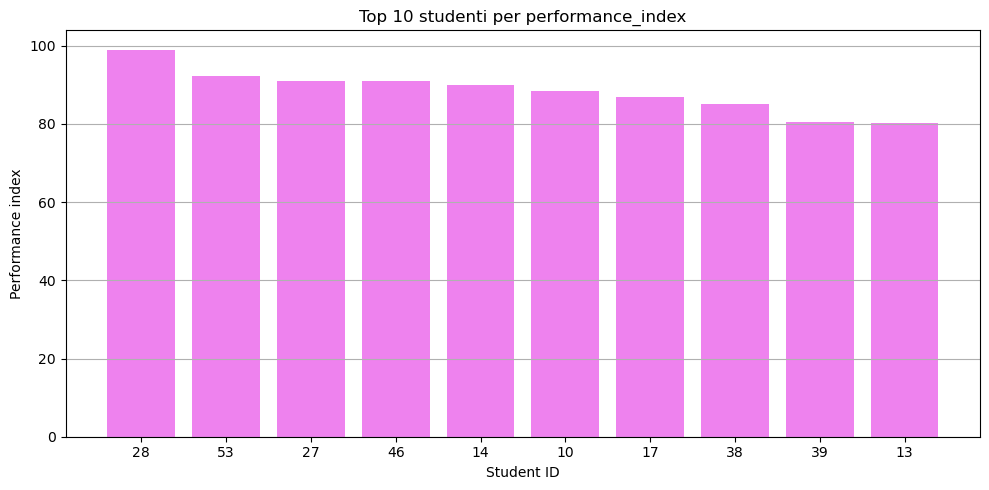

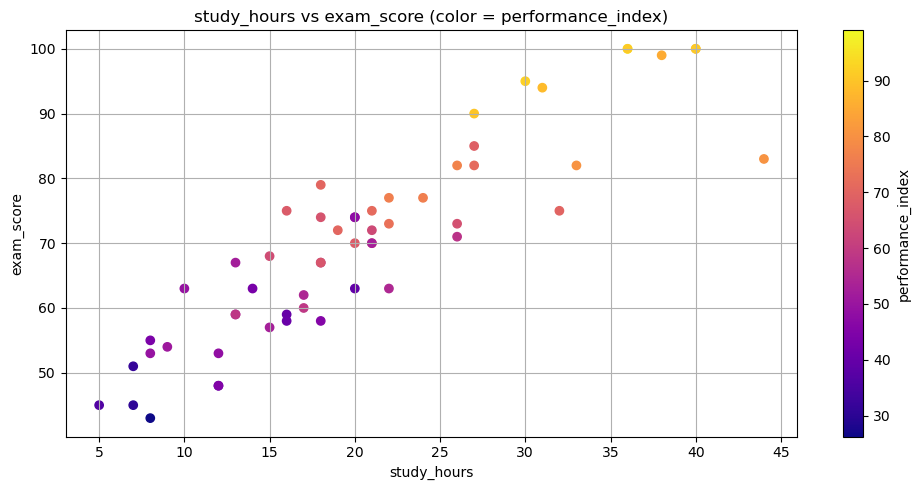

In [4]:
# 1
print('Valori mancanti per colonna: ')
print(df.isnull().sum())
df = df.dropna()

# 2
df['performance_index'] = df['exam_score']*df['attendance']

# 3
df_filtrato = df[(df['study_hours']>20) & (df['attendance']>0.8)]

# 4
top10 = df.nlargest(10, 'performance_index')
plt.figure(figsize=(10,5))
plt.bar(top10['student_id'].astype(str), top10['performance_index'], color='violet')
plt.title('Top 10 studenti per performance_index')
plt.xlabel('Student ID')
plt.ylabel('Performance index')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

# 5
plt.figure(figsize=(10,5))
scatter = plt.scatter(df['study_hours'], df['exam_score'], c=df['performance_index'], cmap='plasma')
plt.colorbar(scatter, label='performance_index')
plt.title('study_hours vs exam_score (color = performance_index)')
plt.xlabel('study_hours')
plt.ylabel('exam_score')
plt.grid(True)
plt.tight_layout()
plt.show()


## Esercizio 5

Utilizza lo stesso dataset `students.csv`.

1. Determina **numero di righe e colonne** del dataset ed elimina la colonna `passed`.

2. Trova il **valore di `exam_score` più frequente**.

3. Calcola la **media del punteggio d’esame (`exam_score`) per fasce di ore di studio**:
   - `0–10`
   - `11–20`
   - `21–30`
   - `>30`

4. Crea un **boxplot** dei valori di `exam_score` raggruppati per fascia di ore di studio.

5. Crea un **violin plot** della distribuzione di `attendance` per ciascuna fascia di ore di studio.


(56, 6)

Valore più frequente: 63.0
fascia
0-10     51.125000
11-20    63.916667
21-30    77.000000
>30      92.555556
Name: exam_score, dtype: float64


C:\Users\Viola\AppData\Local\Temp\ipykernel_4152\1055249634.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=fasce)


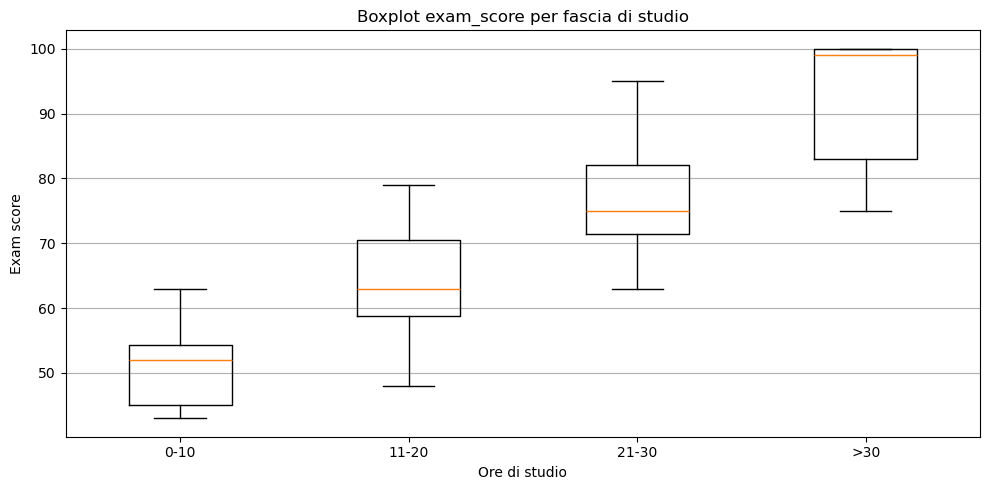

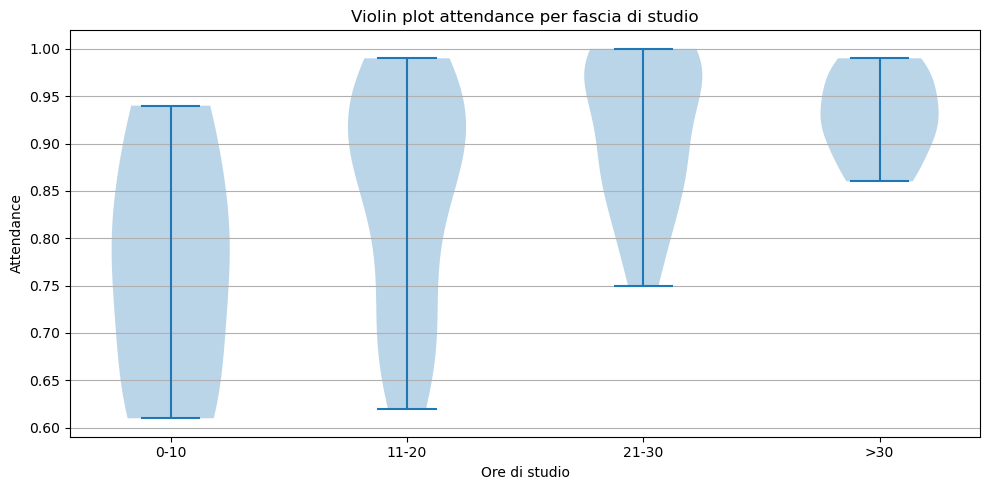

In [6]:
# 1
print(df.shape)
df = df.drop(columns=['passed'])

# 2
print(f"\nValore più frequente: {df['exam_score'].value_counts().idxmax()}")

# 3
df['fascia'] = pd.cut(
    df['study_hours'],
    bins=[0,10,20,30, float('inf')],
    labels=['0-10', '11-20', '21-30', '>30']
)
media_fasce = df.groupby('fascia')['exam_score'].mean()
print(media_fasce)

# 4
fasce = ['0-10', '11-20', '21-30', '>30']
data = [df[df['fascia'] == f]['exam_score'].dropna().values for f in fasce]

plt.figure(figsize=(10, 5))
plt.boxplot(data, labels=fasce)
plt.title('Boxplot exam_score per fascia di studio')
plt.xlabel('Ore di studio')
plt.ylabel('Exam score')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

# 5
data = [df[df['fascia']==f]['attendance'].dropna().values for f in fasce]

plt.figure(figsize=(10, 5))
plt.violinplot(data, positions=range(len(fasce)))
plt.xticks(range(len(fasce)), fasce)
plt.title('Violin plot attendance per fascia di studio')
plt.xlabel('Ore di studio')
plt.ylabel('Attendance')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()


## Esercizio 6

Genera due array:

`x = np.linspace(0, 5, 80)`  
`y = 2.5 * x + 1.2 + np.random.normal(0, 0.5, 80)`

1. Usa `scipy.optimize.curve_fit` per stimare i parametri `a` e `b` della retta del tipo:

    $$
   y = a \cdot x + b
    $$

2. Plotta i punti originali e la retta ottenuta.

3. Calcola **MAE** (Mean Absolute Error) e **RMSE** (Root Mean Squared Error) tra i valori reali `y` e quelli stimati dal modello, dove:  

   $$
   \text{MAE} = \frac{1}{n}\sum_{i=1}^{n} \lvert y_i - \hat{y}_i \rvert
   $$  

   $$
   \text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
   $$


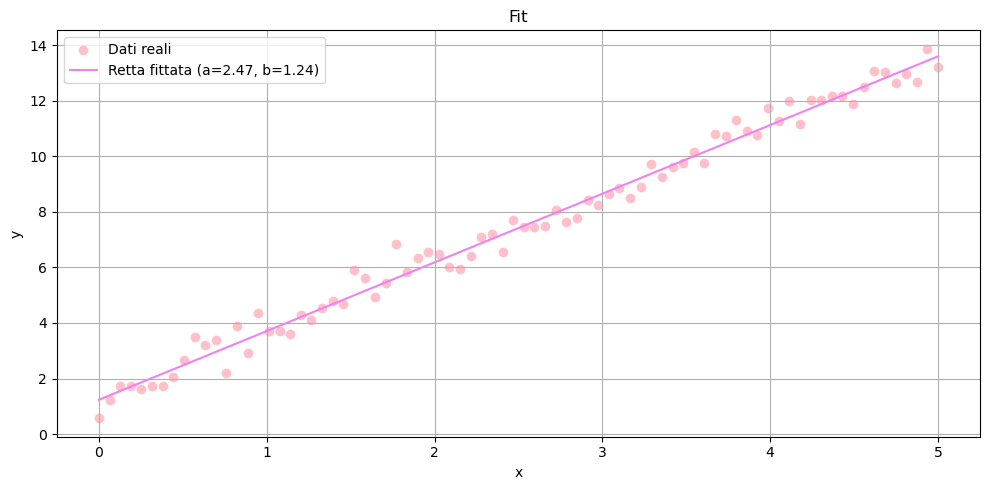

MAE: 0.3308
RMSE: 0.4109


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

x = np.linspace(0, 5, 80)
y = 2.5 * x + 1.2 + np.random.normal(0, 0.5, 80)

# 1
def retta(x,a,b):
    return a*x + b

params,cov = curve_fit(retta,x,y)
a,b = params

# 2
y_fit = retta(x,a,b)

plt.figure(figsize=(10,5))
plt.scatter(x,y, color='pink', label='Dati reali')
plt.plot(x,y_fit, color='violet', label=f'Retta fittata (a={a:.2f}, b={b:.2f})')
plt.title('Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 3
MAE = np.mean(np.abs(y-y_fit))
RMSE = np.sqrt(np.mean((y-y_fit)**2))

print(f"MAE: {MAE:.4f}\nRMSE: {RMSE:.4f}")